In [2]:
# Image
#  ↓
# Patchify
#  ↓

# Context Patches ──► Context Encoder
#                          ↓
#                     Context Tokens
#                          ↓
#                      Predictor
#                          ↓
#                  Predicted Target Tokens

# Target Patches ──► Target Encoder
#                          ↓
#                     Target Tokens

# Loss:
# Predicted Tokens vs Target Tokens

# JEPA V6 - Research Style Implementation

## Goal

Learn representations by predicting the representation of hidden image regions.

Instead of predicting pixels:

Context → Target Pixels

JEPA predicts:

Context Representation → Target Representation

---

## Architecture

Image

 ↓

Patch Embedding

 ↓

Context Patches → Context Encoder → Predictor

Target Patches → Target Encoder

Loss:

Predicted Target Representation

vs

Actual Target Representation

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import datasets
from torchvision import transforms

import matplotlib.pyplot as plt

# Dataset

In [4]:
transform = transforms.ToTensor()

dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=False,
    transform=transform
)

c:\Users\dhana\miniconda3\envs\DL_Torch\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


# patch Embedding

In [5]:
class PatchEmbed(nn.Module):

    def __init__(self, patch_size = 4, embed_dim = 128):
        super().__init__()

        self.proj = nn.Conv2d(in_channels = 3, out_channels = embed_dim, kernel_size = patch_size, stride = patch_size)

    def forward(self, x):
        x = self.proj(x)

        B, C, H, W = x.shape

        x = x.flatten(2)

        x = x.transpose(1, 2)

        return x

# Context Encoder

In [6]:
class ContextEncoder(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(128,256),
            nn.GELU(),

            nn.Linear(256,128)
        )

    def forward(self,x):

        return self.net(x)

# Target Encoder

In [7]:
class TargetEncoder(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(128,256),
            nn.GELU(),

            nn.Linear(256,128)
        )

    def forward(self,x):

        return self.net(x)

# Predictor

In [8]:
class Predictor(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(128,256),
            nn.GELU(),

            nn.Linear(256,128)
        )

    def forward(self,x):

        return self.net(x)

# Create Models

In [9]:
patch_embed = PatchEmbed()

context_encoder = ContextEncoder()

target_encoder = TargetEncoder()

predictor = Predictor()

# Initialize Target Encoder

In [10]:
target_encoder.load_state_dict(
    context_encoder.state_dict()
)

<All keys matched successfully>

# Freeze Target Encoder

In [11]:
for p in target_encoder.parameters():
    p.requires_grad = False

# Optimizer

In [12]:
optimizer = torch.optim.AdamW(
    list(patch_embed.parameters()) +
    list(context_encoder.parameters()) +
    list(predictor.parameters()),
    lr=1e-3
)

# Create Context and Target Masks

In [13]:
def create_masks():

    indices = torch.randperm(64)

    context_idx = indices[:48]

    target_idx = indices[48:]

    return context_idx, target_idx

# Training Loop

In [14]:
for epoch in range(1000):

    idx = torch.randint(
        0,
        len(dataset),
        (1,)
    ).item()

    image,_ = dataset[idx]

    image = image.unsqueeze(0)

    tokens = patch_embed(image)

    context_idx, target_idx = create_masks()

    context_tokens = tokens[:,context_idx,:]

    target_tokens = tokens[:,target_idx,:]

    context_repr = context_encoder(
        context_tokens
    )

    pred_target = predictor(
        context_repr
    )

    with torch.no_grad():

        target_repr = target_encoder(
            target_tokens
        )

    pred_target = pred_target.mean(1)

    target_repr = target_repr.mean(1)

    loss = (
        1 -
        F.cosine_similarity(
            pred_target,
            target_repr,
            dim=1
        ).mean()
    )

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    m = 0.99

    for target_param, context_param in zip(
        target_encoder.parameters(),
        context_encoder.parameters()
    ):

        target_param.data = (
            m * target_param.data
            +
            (1-m) * context_param.data
        )

    if epoch % 100 == 0:

        print(
            f"Epoch {epoch} "
            f"Loss {loss.item():.4f}"
        )

Epoch 0 Loss 1.0740
Epoch 100 Loss 0.0003
Epoch 200 Loss 0.0001
Epoch 300 Loss 0.0001
Epoch 400 Loss 0.0004
Epoch 500 Loss 0.0003
Epoch 600 Loss 0.0024
Epoch 700 Loss 0.0004
Epoch 800 Loss 0.0002
Epoch 900 Loss 0.0001


In [15]:
image, _ = dataset[0]

image.shape

torch.Size([3, 32, 32])

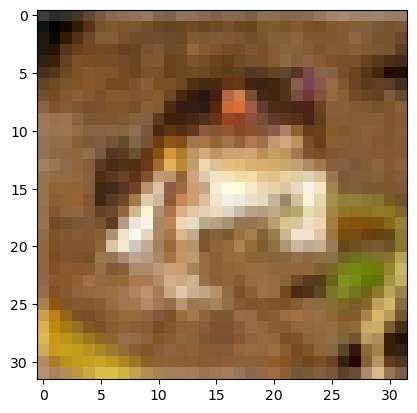

In [16]:
plt.imshow(image.permute(1, 2, 0))

In [17]:
image = image.unsqueeze(0)

image.shape

torch.Size([1, 3, 32, 32])

In [18]:
# patch_emved a custom class

tokens = patch_embed(image)

tokens.shape

torch.Size([1, 64, 128])

In [19]:
context_idx, traget_index = create_masks()

context_tokens = tokens[:, context_idx, :]
traget_tokens = tokens[:, traget_index, :]

print(context_tokens.shape)
print(traget_tokens.shape)

torch.Size([1, 48, 128])
torch.Size([1, 16, 128])


In [20]:
context_repr = context_encoder(context_tokens)

pred_target = predictor(context_repr)

with torch.no_grad():
    target_repr = target_encoder(target_tokens)

In [21]:
pred_target = pred_target.mean(1)

target_repr = target_repr.mean(1)

In [22]:
similarity = F.cosine_similarity(
    pred_target,
    target_repr,
    dim=1
)

print(similarity)

tensor([0.9966], grad_fn=<SumBackward1>)


In [23]:
print("pred_target")
print(pred_target[:, 1:10])
print("target_repr")
print(target_repr[:, 1:10])

pred_target
tensor([[-0.5308,  0.9601,  0.3828,  0.0519,  0.5565, -0.9389, -0.8908,  0.4208,
         -0.4429]], grad_fn=<SliceBackward0>)
target_repr
tensor([[-0.4053,  0.6371,  0.2597,  0.0713,  0.4637, -0.7536, -0.6520,  0.0399,
         -0.3411]])


In [24]:
print(
    F.normalize(pred_target, dim=1)[0][:10]
)

print(
    F.normalize(target_repr, dim=1)[0][:10]
)

tensor([ 0.1442, -0.0509,  0.0920,  0.0367,  0.0050,  0.0533, -0.0900, -0.0854,
         0.0403, -0.0425], grad_fn=<SliceBackward0>)
tensor([ 0.1418, -0.0519,  0.0816,  0.0333,  0.0091,  0.0594, -0.0965, -0.0835,
         0.0051, -0.0437])
